In [1]:
import numpy as np
import pandas as pd

df= pd.read_csv("/content/Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [38]:
df.nunique()

,0
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,72
PhoneService,2
PaperlessBilling,2
MonthlyCharges,1584
TotalCharges,6530
Churn,2


In [33]:
df["TotalCharges"].dtype

dtype('float64')

In [34]:
df = df.dropna()

In [40]:
binary_cols = ["gender","Partner","Dependents",'PhonService','PaperlessBilling','Churn']

In [41]:
binary_cols = ["gender","Partner","Dependents","PhoneService","PaperlessBilling","Churn"]
for col in binary_cols:
  df[col] = df[col].replace({"Yes":1, "No":0, "Male":1, "Female":0})

In [42]:
categorical_cols = ["MultipleLines","InternetService","OnlineSecurity","OnlineBackup",
                    "DeviceProtection","TechSupport","StreamingTV","StreamingMovies",
                    "Contract","PaymentMethod"]

In [44]:
cols_to_dummy = [col for col in categorical_cols if col in df.columns]
if cols_to_dummy:
    df = pd.get_dummies(df, columns=cols_to_dummy, drop_first=True)

In [45]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

In [46]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

In [47]:
X = df.drop("Churn", axis=1)  # features
y = df["Churn"]               # target

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
X_train.shape

(5625, 30)

In [50]:
X_test.shape

(1407, 30)

In [51]:
from sklearn.linear_model import LogisticRegression

In [52]:
model= LogisticRegression(max_iter=1000)

In [53]:
df = df.dropna()

In [54]:
X.dtypes

,0
gender,int64
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
PaperlessBilling,int64
MonthlyCharges,float64
TotalCharges,float64
MultipleLines_No phone service,bool


In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [56]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [57]:
y_pred = model.predict(X_test)

In [64]:
from sklearn.metrics import accuracy_score
print("Logistic  Accuracy:", accuracy_score(y_test, y_pred))

Logistic  Accuracy: 0.7882018479033405


In [59]:
from sklearn.ensemble import RandomForestClassifier

In [60]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [61]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [62]:
y_pred_rf = rf_model.predict(X_test)

In [63]:
from sklearn.metrics import accuracy_score

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7882018479033405


In [65]:
(y_pred == y_pred_rf).sum()

np.int64(1245)

In [66]:
from sklearn.metrics import classification_report

print("Logistic:\n", classification_report(y_test, y_pred))
print("Random Forest:\n", classification_report(y_test, y_pred_rf))

Logistic:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

Random Forest:
               precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.64      0.46      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.78      1407



In [67]:
from sklearn.metrics import confusion_matrix

print("Logistic:\n", confusion_matrix(y_test, y_pred))
print("Random Forest:\n", confusion_matrix(y_test, y_pred_rf))

Logistic:
 [[916 117]
 [181 193]]
Random Forest:
 [[936  97]
 [201 173]]


In [68]:
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

,0
TotalCharges,0.193968
MonthlyCharges,0.167620
tenure,0.165879
InternetService_Fiber optic,0.039835
PaymentMethod_Electronic check,0.037079
gender,0.029085
Contract_Two year,0.029049
PaperlessBilling,0.026621
OnlineSecurity_Yes,0.026389
Contract_One year,0.025441


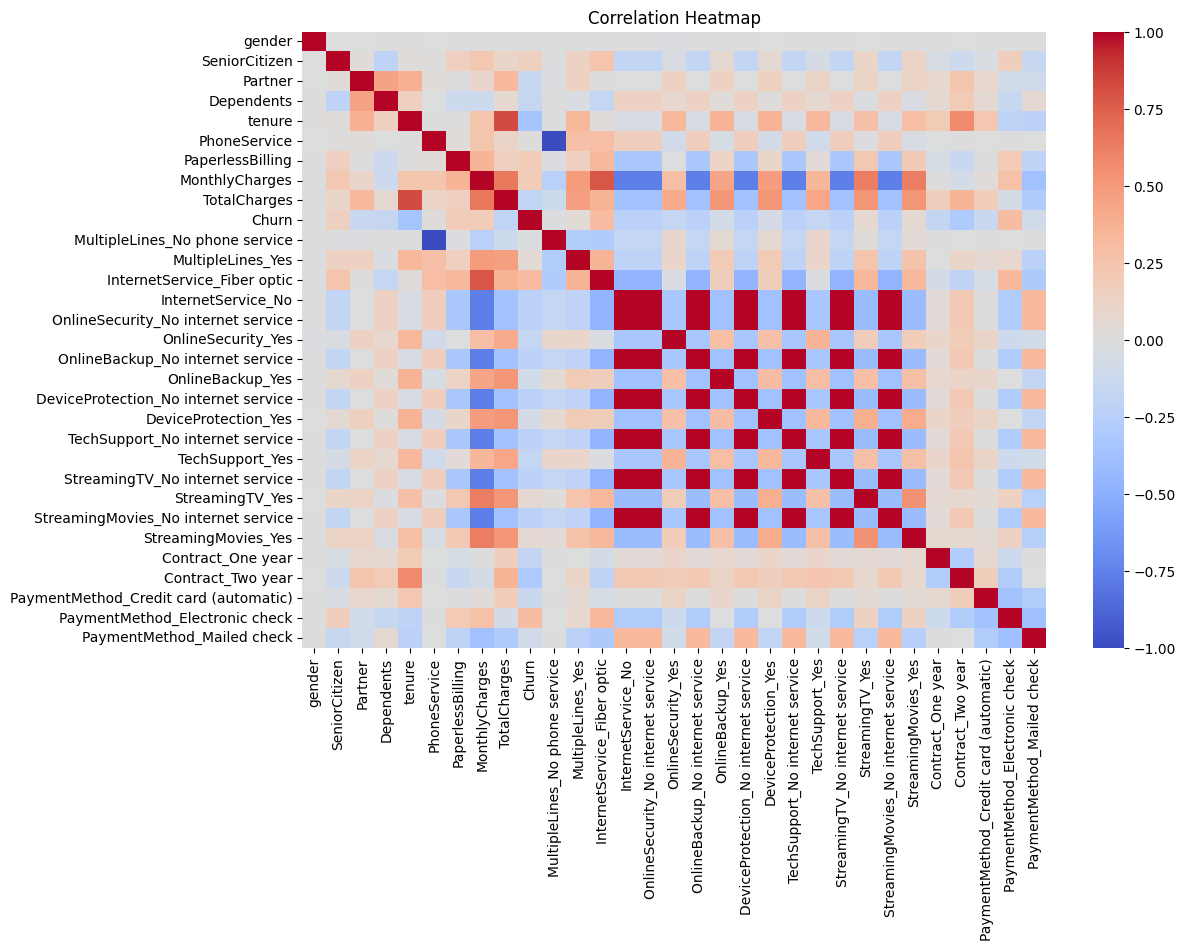

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

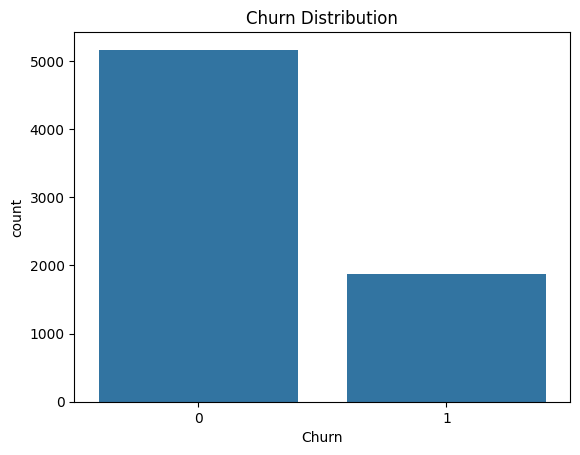

In [70]:
sns.countplot(x=y)
plt.title("Churn Distribution")
plt.show()

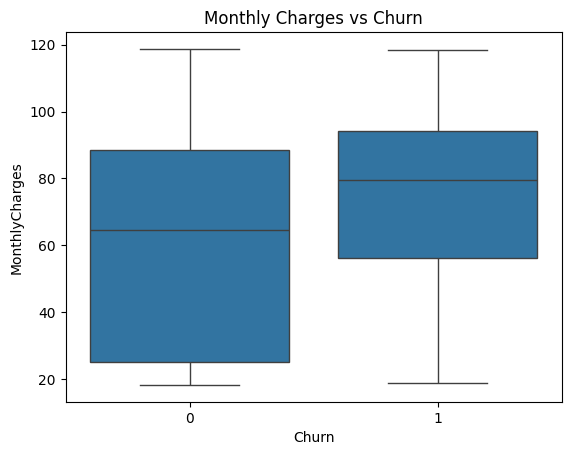

In [71]:
sns.boxplot(x=y, y=df["MonthlyCharges"])
plt.title("Monthly Charges vs Churn")
plt.show()

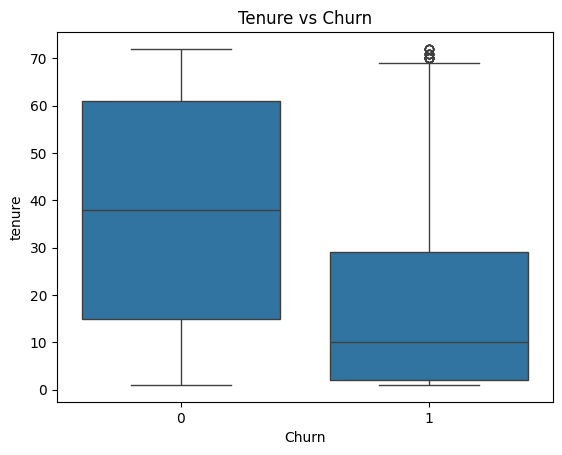

In [72]:
sns.boxplot(x=y, y=df["tenure"])
plt.title("Tenure vs Churn")
plt.show()

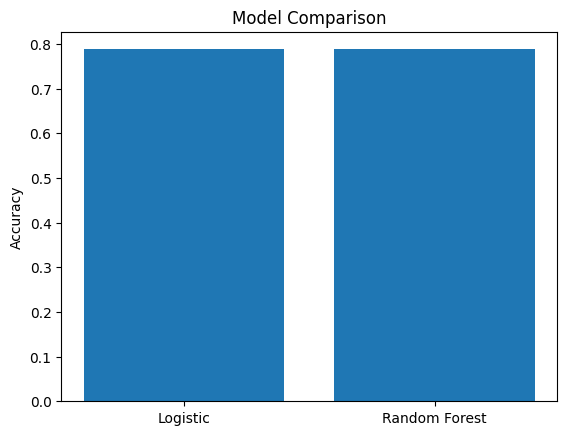

In [73]:
models = ["Logistic", "Random Forest"]
accuracy = [0.788, 0.788]

plt.bar(models, accuracy)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

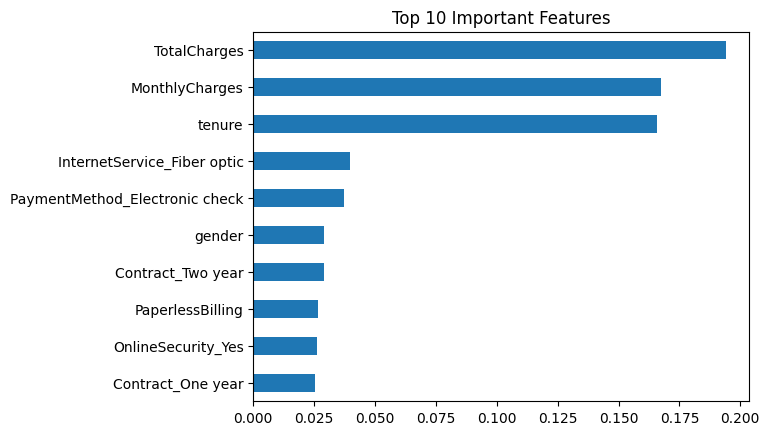

In [74]:
importance.sort_values(ascending=True).tail(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()